# Time-Aware Lag Modeling and Interpretability

## Goal
This notebook does the follow-up work:

1. compare **linear coefficients** vs **tree importances**
2. check **feature-importance stability** across multiple seeds
3. create **partial dependence plots** for the strongest tree features
4. build a **lag-based forecasting baseline** using prior-year country history

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay

from life_expectancy.analysis.diagnostics import (
    group_error_table,
    plot_predicted_vs_actual,
    worst_errors_table,
)
from life_expectancy.data.preprocessing import build_processed_dataset
from life_expectancy.features.feature_selection import build_feature_sets_abc
from life_expectancy.features.temporal import make_country_lag_features
from life_expectancy.modeling.experiments.core import run_time_experiment
from life_expectancy.modeling.registries import get_default_model_registry
from life_expectancy.modeling.splits import make_time_split

In [3]:
from life_expectancy.data.utils import resolve_project_path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CONFIG_PATH = PROJECT_ROOT / "configs" / "default.yaml"

with CONFIG_PATH.open("r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

config["project"]["root"] = str(PROJECT_ROOT)

PROCESSED = resolve_project_path(config, "data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)
TARGET = config["features"].get("target_col", "life_expectancy")
YEAR_COL = config["features"].get("year_col", "year")
TEST_YEARS = config.get("modeling", {}).get("split", {}).get("test_years", 3)
RANDOM_STATE = config.get("random_seed", 42)

REPORT_TABLES = PROJECT_ROOT / "reports" / "tables"
REPORT_FIGURES = PROJECT_ROOT / "reports" / "figures"

REPORT_TABLES.mkdir(parents=True, exist_ok=True)
REPORT_FIGURES.mkdir(parents=True, exist_ok=True)

RUN_LOG = REPORT_TABLES / "advanced_model_run_log.csv"

print("Project root:", PROJECT_ROOT)
print("Processed dir:", PROCESSED)
print("Target:", TARGET)


sns.set_theme(style="whitegrid")

Project root: /Users/aleksia/Desktop/RND4IMPACT Projects/life-expectancy-analysis
Processed dir: /Users/aleksia/Desktop/RND4IMPACT Projects/life-expectancy-analysis/data/processed
Target: life_expectancy


In [4]:
df, _ = build_processed_dataset(config)

model_df, feature_sets, feature_meta = build_feature_sets_abc(df, config)

model_df.shape, {k: len(v) for k, v in feature_sets.items()}

((2265, 40), {'A': 38, 'B': 31, 'C': 5})

## Linear coefficients vs tree importances
To keep this comparison interpretable, use Feature Set C (the smaller manually reduced set).

In [5]:
registry = get_default_model_registry(random_state=RANDOM_STATE)

ridge_row, ridge_pred, _, ridge_pipe = run_time_experiment(
    df=model_df,
    feature_list=feature_sets["C"],
    target_col=TARGET,
    year_col=YEAR_COL,
    model_name="ridge",
    model=registry["ridge"]["model"],
    scale_numeric=registry["ridge"]["scale_numeric"],
    test_years=TEST_YEARS,
)

rf_row, rf_pred, _, rf_pipe = run_time_experiment(
    df=model_df,
    feature_list=feature_sets["C"],
    target_col=TARGET,
    year_col=YEAR_COL,
    model_name="rf",
    model=registry["rf"]["model"],
    scale_numeric=registry["rf"]["scale_numeric"],
    test_years=TEST_YEARS,
)

et_row, et_pred, _, et_pipe = run_time_experiment(
    df=model_df,
    feature_list=feature_sets["C"],
    target_col=TARGET,
    year_col=YEAR_COL,
    model_name="extra_trees",
    model=registry["extra_trees"]["model"],
    scale_numeric=registry["extra_trees"]["scale_numeric"],
    test_years=TEST_YEARS,
)

In [6]:
ridge_coef = ridge_pipe.named_steps["model"].coef_

ridge_df = pd.DataFrame({
    "feature": feature_sets["C"],
    "ridge_coef": ridge_coef,
    "abs_coef": np.abs(ridge_coef),
}).sort_values("abs_coef", ascending=False)

rf_df = pd.DataFrame({
    "feature": feature_sets["C"],
    "rf_importance": rf_pipe.named_steps["model"].feature_importances_,
})

et_df = pd.DataFrame({
    "feature": feature_sets["C"],
    "et_importance": et_pipe.named_steps["model"].feature_importances_,
})

driver_compare = (
    ridge_df[["feature", "ridge_coef", "abs_coef"]]
    .merge(rf_df, on="feature")
    .merge(et_df, on="feature")
)

driver_compare.to_csv(REPORT_TABLES / "driver_compare_C.csv", index=False)

driver_compare

,feature,ridge_coef,abs_coef,rf_importance,et_importance
0,hiv_aids,-4.866201,4.866201,0.493354,0.489289
1,status_flag,2.635828,2.635828,0.060672,0.234145
2,percentage_expenditure,1.972507,1.972507,0.184917,0.162088
3,infant_deaths,-1.092126,1.092126,0.236558,0.096907
4,year,0.507397,0.507397,0.024499,0.017571


## Importance stability across random seeds
This checks whether the tree-based importance ranking is stable or highly seed-dependent.

In [7]:
stability_rows = []

for seed in [42, 43, 44]:
    model = RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=seed,
        n_jobs=-1,
    )

    row, pred_df, _, pipe = run_time_experiment(
        df=model_df,
        feature_list=feature_sets["B"],
        target_col=TARGET,
        year_col=YEAR_COL,
        model_name=f"rf_seed_{seed}",
        model=model,
        scale_numeric="none",
        test_years=TEST_YEARS,
    )

    importances = pipe.named_steps["model"].feature_importances_

    for feat, imp in zip(feature_sets["B"], importances):
        stability_rows.append({
            "seed": seed,
            "feature": feat,
            "importance": imp,
        })

stability_df = pd.DataFrame(stability_rows)

stability_summary = (
    stability_df.groupby("feature")["importance"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
    .reset_index()
)

stability_summary.head(10)

,feature,mean,std
0,hiv_aids,0.650836,0.000359
1,income_composition_of_resources,0.164399,0.001347
2,adult_mortality,0.082318,0.001944
3,infant_deaths,0.020187,0.000928
4,schooling,0.015618,0.000741
5,bmi,0.014598,0.000650
6,thinness_1_19_years,0.006949,0.000245
7,alcohol,0.005218,0.000319
8,undernourishment,0.003824,0.000226
9,health_expenditure_percent,0.003377,0.000156


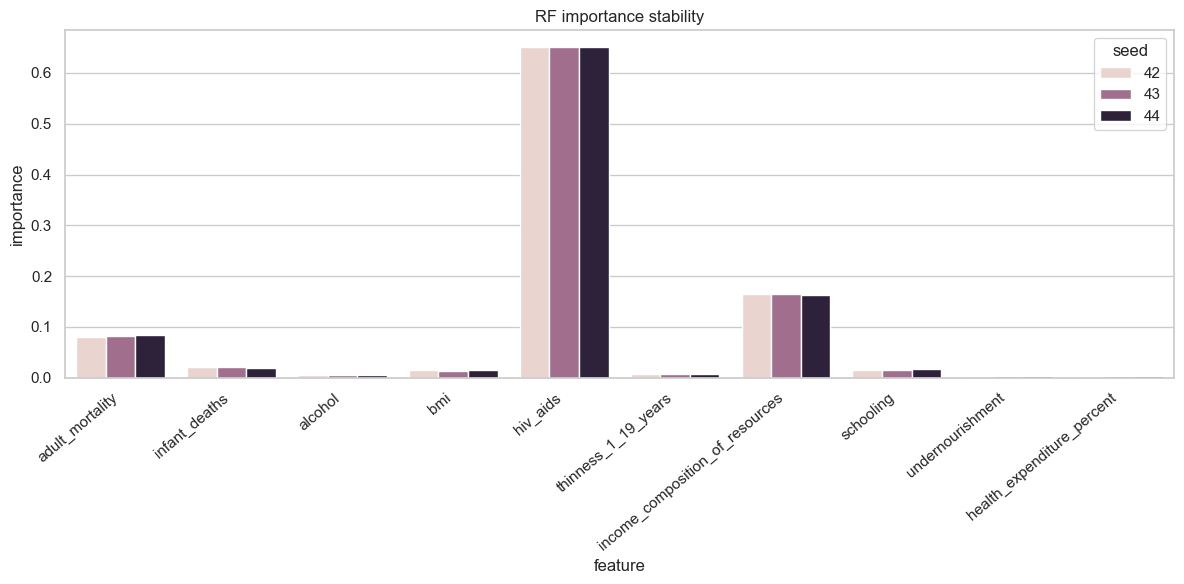

In [8]:
top_features = stability_summary.head(10)["feature"]

plot_df = stability_df[stability_df["feature"].isin(top_features)]

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_df,
    x="feature",
    y="importance",
    hue="seed",
)

plt.xticks(rotation=40, ha="right")
plt.title("RF importance stability")
plt.tight_layout()
plt.show()

## Partial dependence for top tree features
Use the best tree model on Feature Set C so the plots remain readable.

In [9]:
best_tree_pipe = rf_pipe if rf_row["rmse"] <= et_row["rmse"] else et_pipe
best_tree_name = "rf" if rf_row["rmse"] <= et_row["rmse"] else "extra_trees"

importance_df = rf_df if best_tree_name == "rf" else et_df

top2 = importance_df.sort_values(
    importance_df.columns[1],
    ascending=False,
)["feature"].head(2).tolist()

top2

['hiv_aids', 'infant_deaths']

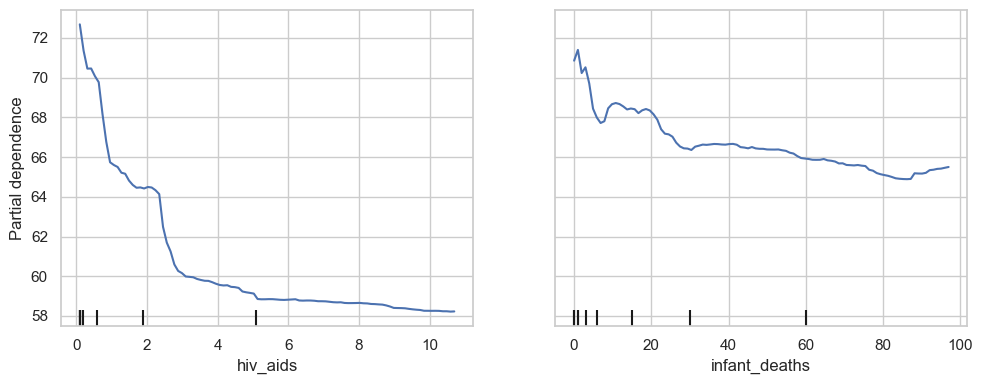

In [10]:
keep_cols = list(dict.fromkeys([*feature_sets["C"], TARGET, YEAR_COL]))

work_df = model_df[keep_cols]

X_train, _, y_train, _, _ = make_time_split(
    work_df,
    target_col=TARGET,
    year_col=YEAR_COL,
    test_years=TEST_YEARS,
)

Xtr = X_train[feature_sets["C"]]

# fix sklearn warning
Xtr = Xtr.astype(float)

fig, ax = plt.subplots(figsize=(10, 4))

PartialDependenceDisplay.from_estimator(
    best_tree_pipe,
    Xtr,
    features=top2,
    ax=ax,
)

plt.tight_layout()
plt.show()

## Lag-based forecasting baseline
This is the clean temporal extension: use previous country-year information to predict later life expectancy on the same time-aware split.

In [12]:
base_numeric = model_df.copy()

metadata_cols = [
    col
    for col in ["country", "country_code", "region", "income_group", YEAR_COL]
    if col in df.columns
]

metadata = df[metadata_cols].copy()
metadata[YEAR_COL] = pd.to_numeric(metadata[YEAR_COL], errors="raise").astype(int)

lag_source_df = pd.concat(
    [
        metadata.reset_index(drop=True),
        base_numeric.reset_index(drop=True),
    ],
    axis=1,
)

lag_source_df = lag_source_df.loc[:, ~lag_source_df.columns.duplicated()]
lag_source_df = lag_source_df.dropna(subset=["country", YEAR_COL, TARGET]).copy()

lag_base_features = [feature for feature in feature_sets["C"] if feature != YEAR_COL]

lagged_df = make_country_lag_features(
    df=lag_source_df,
    target_col=TARGET,
    country_col="country",
    year_col=YEAR_COL,
    feature_cols=lag_base_features,
    lags=(1, 2, 3),
)

lag_feature_cols = [
    col
    for col in lagged_df.columns
    if col not in {"country", "country_code", "region", "income_group", TARGET}
]

len(lag_feature_cols), lagged_df.shape

(55, (1812, 60))

In [13]:
lag_ridge_row, lag_ridge_pred, _, _ = run_time_experiment(
    df=lagged_df,
    feature_list=lag_feature_cols,
    target_col=TARGET,
    year_col=YEAR_COL,
    model_name="lag_ridge",
    model=registry["ridge"]["model"],
    scale_numeric=registry["ridge"]["scale_numeric"],
    test_years=TEST_YEARS,
)

lag_hgb_row, lag_hgb_pred, _, _ = run_time_experiment(
    df=lagged_df,
    feature_list=lag_feature_cols,
    target_col=TARGET,
    year_col=YEAR_COL,
    model_name="lag_hgb",
    model=registry["hgb"]["model"],
    scale_numeric=registry["hgb"]["scale_numeric"],
    test_years=TEST_YEARS,
)

pd.DataFrame([lag_ridge_row, lag_hgb_row]).sort_values("rmse")

,model_name,split_name,n_train,n_test,rmse,mae,r2
1,lag_hgb,time,1359,453,0.782090,0.468453,0.991272
0,lag_ridge,time,1359,453,0.934932,0.532570,0.987527


In [17]:
best_pred = lag_ridge_pred if lag_ridge_row["rmse"] <= lag_hgb_row["rmse"] else lag_hgb_pred

worst10 = worst_errors_table(best_pred)
mae_by_year = group_error_table(best_pred, group_col=YEAR_COL)

display(worst10)
display(mae_by_year.head())

,country,year,y_true,y_pred,error,abs_error
0,South Africa,2013,65.049500,59.982106,-5.067394,5.067394
1,Iraq,2013,69.468500,73.395319,3.926819,3.926819
2,Trinidad and Tobago,2013,71.791000,75.500971,3.709971,3.709971
3,Germany,2014,85.045122,81.621000,-3.424122,3.424122
4,Angola,2013,54.577000,57.434906,2.857906,2.857906
5,Zimbabwe,2015,63.267000,60.422031,-2.844969,2.844969
6,Uganda,2013,63.440500,60.612666,-2.827834,2.827834
7,Ukraine,2014,74.593293,72.048623,-2.544670,2.544670
8,Finland,2014,85.090244,82.545579,-2.544665,2.544665
9,Afghanistan,2015,64.188500,61.675884,-2.512616,2.512616


,year,n,mae,rmse
0,2014,151,0.498917,0.796428
1,2013,151,0.491236,0.910115
2,2015,151,0.415204,0.610237


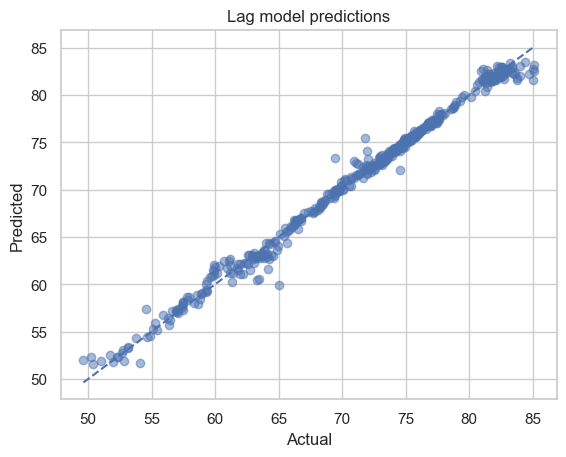

In [18]:
plot_predicted_vs_actual(
    best_pred["y_true"],
    best_pred["y_pred"],
    title="Lag model predictions",
)

plt.show()